In [1]:
!git clone https://github.com/JusticeZzy/FunduSegmenter.git

%cd FunduSegmenter

d:\Projects\College\Rabcl\Segementation\FunduSegmenter


In [2]:
!python --version

Python 3.11.5


In [4]:
!find . -maxdepth 3 -type f | sort

FIND: Parameter format not correct


In [ ]:
!pip uninstall torch

^C


: 

In [8]:
!pip show torch

Name: torch
Version: 2.13.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License-Expression: Apache-2.0 AND Apache-2.0 WITH LLVM-exception AND BSD-2-Clause AND BSD-3-Clause AND BSL-1.0 AND MIT
Location: C:\Users\DARSHAN\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: accelerate, monai, timm, torchaudio, torchvision


In [5]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [3]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [7]:
!pip install -q monai timm einops albumentations opencv-python ml-collections tensorboard chardet scikit-learn

  error: subprocess-exited-with-error
  
  × Building wheel for stringzilla (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [371 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-311\test
      copying test\cipher.py -> build\lib.win-amd64-cpython-311\test
      copying test\conftest.py -> build\lib.win-amd64-cpython-311\test
      copying test\doctests.py -> build\lib.win-amd64-cpython-311\test
      copying test\find.py -> build\lib.win-amd64-cpython-311\test
      copying test\fingerprints.py -> build\lib.win-amd64-cpython-311\test
      copying test\hash.py -> build\lib.win-amd64-cpython-311\test
      copying test\similarities.py -> build\lib.win-amd64-cpython-311\test
      copying test\sort.py -> build\lib.win-amd64-cpython-311\test
      copying test\string.py -> build\lib.win-amd64-cpython-311\test
      copying test\stringzillas.py -> build\lib.win-amd64-cpython-311\test
      cop

In [5]:
%cd /content/FunduSegmenter

!sed -n '1,300p' model/fundusegmenter.py

/content/FunduSegmenter
"""
MIT License

Copyright (c) 2021 Robin Strudel
Copyright (c) INRIA

Partly revised from https://github.com/rstrudel/segmenter
by Zhenyi Zhao @Vampire,Computing,University of Dundee
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class FunduSegmenter(nn.Module):
    def __init__(
        self,
        pre_adapter,
        encoder,
        decoder,
        post_adapter,
    ):
        super().__init__()
        self.patch_size = encoder.patch_size
        self.pre_adapter = pre_adapter
        self.encoder = encoder
        self.decoder = decoder
        self.post_adapter = post_adapter

    @torch.jit.ignore
    def no_weight_decay(self):
        def append_prefix_no_weight_decay(prefix, module):
            return set(map(lambda x: prefix + x, module.no_weight_decay()))

        nwd_params = append_prefix_no_weight_decay("encoder.", self.encoder).union(
            append_prefix_no_weight_decay("decoder.", self.decoder)
        )
   

In [8]:
!sed -n '1,260p' utils/transform.py

"""
MIT License

Copyright (c) 2025 Zhenyi Zhao
Copyright (c) University of Dundee
"""


import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2


def no_transform(image_size):
    transform_image = A.Compose([])    
    
    transform_both = A.Compose(
        [A.Resize(height=image_size, width=image_size, interpolation=cv2.INTER_AREA, mask_interpolation=cv2.INTER_NEAREST),
         A.ToFloat(),
         A.Normalize(normalization='standard', max_pixel_value=1),
         ToTensorV2(),
        ])
    return transform_image, transform_both

def spatial_transform(image_size):
    transform_image = A.Compose([])    
        
    transform_both = A.Compose(
        [A.Rotate(limit=15, interpolation=cv2.INTER_CUBIC, p=0.5),
         A.VerticalFlip(p=0.5),
         A.HorizontalFlip(p=0.5),
         A.Resize(height=image_size, width=image_size, interpolation=cv2.INTER_AREA, mask_interpolation=cv2.INTER_NEAREST),
         A.ToFloat(),
         A.Normalize(normalizati

In [9]:
!sed -n '1,350p' test.py

"""
MIT License

Copyright (c) 2025 Zhenyi Zhao
Copyright (c) University of Dundee
"""


import argparse
import monai
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch.nn import functional as F

from model.fundusegmenter import FunduSegmenter
from model.modules.vit import VisionTransformer
from model.modules.segmenter_decoder import SegmenterDecoder
from model.modules.adapters import PreAdapter, PostAdapter
from model.baselines.dunet import DUNet
from model.baselines.retfoundsegmenter import RETFoundSegmenter
from model.baselines.transunet.networks.vit_seg_modeling import VisionTransformer as TransUNet
from model.baselines.transunet.networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from utils.transform import validation_transform
from utils.datasets import ReconstructTestDataset
from utils.metrics import bootstrap


def get_args_parser():
    parser = argparse.ArgumentParser('test FunduSegm

In [11]:
!find . -type f \( \
    -iname "*.pth" -o \
    -iname "*.pt" -o \
    -iname "*.ckpt" -o \
    -iname "*.pth.tar" \
\) -print

In [12]:
!grep -Rni "best_weights\|saved_weights\|checkpoint\|pth" README.md test.py train.py .

README.md:48:Download RETFound pre-trained weights ```RETFound_mae_natureCFP.pth``` from [RETFound](https://github.com/rmaphoh/RETFound), and save it in ```FunduSegmenter```.
README.md:117:Download the pre-trained [DUNet](https://www.sciencedirect.com/science/article/abs/pii/S0169260721000444?casa_token=19OZFuiKaQsAAAAA:3qza9yDwFd8qhnzq_73CReq3HQ5rjWV6Xv5f_6MNsBJceS_72dyjsg_pXieKBss2iLLuWl7qQJg) weights from [here](https://huggingface.co/JusticeZzy/FunduSegmenter) (DUNet_OD_CentreCrop_pretrained.pth). We pre-trained it on Drishti-GS, RIM-ONE-r3, REFUGE training, and REFUGE validation. DUNet is one of the baseline models. You can train your own weights by following the step 4. Alternatively, you can use any other reliable pre-trained weights to apply OD centre cropping pre-processing.
README.md:126:  --checkpoint_path ./DUNet_OD_CentreCrop_pretrained.pth \
README.md:163:  --checkpoint_path ./results/saved_weights/best_weights.pth \
README.md:174:  --checkpoint_path ./results/saved_weigh

In [13]:
!sed -n '1,260p' README.md

# FunduSegmenter
This is the official PyTorch implementation of [FunduSegmenter: Leveraging the RETFound Foundation Model for Joint Optic Disc and Optic Cup Segmentation in Retinal Fundus Images](https://doi.org/10.1167/tvst.15.5.14), the first adaptation of [RETFound](https://doi.org/10.1038/s41586-023-06555-x) for joint optic disc and optic cup segmentation in fundus images.

Weights and processed datasets: [Hugging Face - JusticeZzy/FunduSegmenter](https://huggingface.co/JusticeZzy/FunduSegmenter).

---

If you use our code and publish your work, please:

1. include the following acknowledgment in any publication or website reporting your work:

FunduSegmenter was created by Zhenyi Zhao of the University of Dundee, UK.

2. Cite the following paper:

Zhao, Z., Mookiah, M. R. K., & Trucco, E. (2026). FunduSegmenter: Leveraging the RETFound Foundation Model for Joint Optic Disc and Optic Cup Segmentation in Retinal Fundus Images. _Translational Vision Science & Technology_, 15(5), 14-1

In [4]:
import urllib.request

url = "https://huggingface.co/JusticeZzy/FunduSegmenter/resolve/main/FunduSegmenter_CroppedImage.pth"
filename = "FunduSegmenter_CroppedImage.pth"

print("Downloading file...")
urllib.request.urlretrieve(url, filename)
print("Download complete!")

KeyboardInterrupt: 

In [7]:
!ls -lh FunduSegmenter_CroppedImage.pth

-rw-r--r-- 1 root root 1.6G Aug 26 14:58 FunduSegmenter_CroppedImage.pth


In [8]:
!wget -O DUNet_OD_CentreCrop_pretrained.pth \
"https://huggingface.co/JusticeZzy/FunduSegmenter/resolve/main/DUNet_OD_CentreCrop_pretrained.pth"

--2026-08-26 15:18:49--  https://huggingface.co/JusticeZzy/FunduSegmenter/resolve/main/DUNet_OD_CentreCrop_pretrained.pth
Resolving huggingface.co (huggingface.co)... 13.35.202.97, 13.35.202.40, 13.35.202.121, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.97|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/694d7107dac96f756347246d/10064f78814f5c2c598be2f90267d0144d108e8dbaf7964bb0441c11f1867f3b?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27DUNet_OD_CentreCrop_pretrained.pth%3B+filename%3D%22DUNet_OD_CentreCrop_pretrained.pth%22%3B&user_id=public&X-Xet-Cas-Uid=public&Expires=1787761129&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjk0ZDcxMDdkYWM5NmY3NTYzNDcyNDZkLzEwMDY0Zjc4ODE0ZjVjMmM1OThiZTJmOTAyNjdkMDE0NGQxMDhlOGRiYWY3OTY0YmIwNDQxYzExZjE4NjdmM2JcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomdXNlcl9pZD1wdWJsaWMmWC1YZXQtQ2FzLVVpZD1wdWJsaWMiLC

In [5]:
!ls -lh *.pth

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [12]:
import torch

ckpt = torch.load(
    r"D:\Projects\College\Rabcl\FunduSegmenter_CroppedImage.pth",
    map_location="cpu",
    weights_only=False
)

print(f"Checkpoint type: {type(ckpt)}")

if isinstance(ckpt, dict):
    print("\nCheckpoint keys:")
    for key in ckpt.keys():
        print(f"- {key}")

Checkpoint type: <class 'dict'>

Checkpoint keys:
- model
- optimizer
- epoch


In [11]:
%cd /content/FunduSegmenter

!grep -Rni "FunduSegmenter" . --exclude="*.ipynb" | head -100

/content/FunduSegmenter
./train.py:24:from model.fundusegmenter import FunduSegmenter
./train.py:41:    parser = argparse.ArgumentParser('FunduSegmenter for OD/OC segmentation', add_help=False)
./train.py:50:    parser.add_argument('--model_selection', default='FunduSegmenter', type=str,
./train.py:51:                        help='select model from FunduSegmenter, baseline_RETFoundSegmenter, baseline_DUNet or baseline_TransUNet')
./train.py:103:    # FunduSegmenter
./train.py:104:    if args.model_selection == 'FunduSegmenter':
./train.py:146:        model = FunduSegmenter(pre_adapter=pre_adapter, encoder=encoder, decoder=decoder, post_adapter=post_adapter)       
./model/fundusegmenter.py:16:class FunduSegmenter(nn.Module):
./README.md:1:# FunduSegmenter
./README.md:2:This is the official PyTorch implementation of [FunduSegmenter: Leveraging the RETFound Foundation Model for Joint Optic Disc and Optic Cup Segmentation in Retinal Fundus Images](https://doi.org/10.1167/tvst.15.5.14), th

In [20]:
!sed -n '1,230p' test.py

"""
MIT License

Copyright (c) 2025 Zhenyi Zhao
Copyright (c) University of Dundee
"""


import argparse
import monai
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch.nn import functional as F

from model.fundusegmenter import FunduSegmenter
from model.modules.vit import VisionTransformer
from model.modules.segmenter_decoder import SegmenterDecoder
from model.modules.adapters import PreAdapter, PostAdapter
from model.baselines.dunet import DUNet
from model.baselines.retfoundsegmenter import RETFoundSegmenter
from model.baselines.transunet.networks.vit_seg_modeling import VisionTransformer as TransUNet
from model.baselines.transunet.networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from utils.transform import validation_transform
from utils.datasets import ReconstructTestDataset
from utils.metrics import bootstrap


def get_args_parser():
    parser = argparse.ArgumentParser('test FunduSegm

In [22]:
!find networks -maxdepth 3 -type f | sort

find: ‘networks’: No such file or directory


In [13]:
import torch

from model.fundusegmenter import FunduSegmenter
from model.modules.vit import VisionTransformer
from model.modules.segmenter_decoder import SegmenterDecoder
from model.modules.adapters import PreAdapter, PostAdapter

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

image_size = 224
output_channel = 3
norm = "bn"

# -----------------------------
# Pre-adapter
# -----------------------------
pre_adapter = PreAdapter(
    input_channel=3,
    mid_channel=64,
    norm=norm
)

# -----------------------------
# RETFound ViT encoder
# -----------------------------
encoder = VisionTransformer(
    image_size=(224, 224),
    patch_size=16,
    n_layers=24,
    d_model=1024,
    d_ff=4096,
    n_heads=16,
    n_cls=1000,
    dropout=0.0,
    drop_path_rate=0.0,
    distilled=False,
    channels=3,
)

# -----------------------------
# Segmenter decoder
# -----------------------------
decoder = SegmenterDecoder(
    n_cls=output_channel,
    patch_size=16,
    d_encoder=1024,
    n_layers=2,
    n_heads=16,
    d_model=1024,
    d_ff=4096,
    drop_path_rate=0.0,
    dropout=0.1,
)

# -----------------------------
# Post-adapter
# -----------------------------
post_adapter = PostAdapter(
    input_channel=output_channel,
    mid_channel=64,
    output_channel=output_channel,
    norm=norm
)

# -----------------------------
# FunduSegmenter
# -----------------------------
model = FunduSegmenter(
    pre_adapter=pre_adapter,
    encoder=encoder,
    decoder=decoder,
    post_adapter=post_adapter
)

print("Model constructed successfully.")
print("Device:", device)

c:\Users\DARSHAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model constructed successfully.
Device: cuda


In [15]:
CHECKPOINT_PATH = (
    r"D:\Projects\College\Rabcl\FunduSegmenter_CroppedImage.pth"
)

print("Loading checkpoint...")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint keys:", checkpoint.keys())

checkpoint_model = checkpoint["model"]

msg = model.load_state_dict(
    checkpoint_model,
    strict=True
)

print("✅ FunduSegmenter weights loaded successfully")
print(msg)

Loading checkpoint...
Checkpoint keys: dict_keys(['model', 'optimizer', 'epoch'])
✅ FunduSegmenter weights loaded successfully
<All keys matched successfully>


In [16]:
model.to(device)
model.eval()

print("✅ Model moved to:", device)

✅ Model moved to: cuda


In [26]:
!sed -n '1,350p' model/baselines/dunet.py

"""
Adapted from Mookiah 'M R K, Hogg S, MacGillivray T, et al. On the quantitative effects of compression of retinal fundus images on morphometric vascular measurements in VAMPIRE[J]. Computer methods and programs in biomedicine, 2021, 202: 105969.'

Implement by Zhenyi Zhao @Vampire,Computing,University of Dundee
"""


import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, in_ch=3, out_ch=32):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1, dilation=1)
        self.conv2 = nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=2, dilation=2)
        self.conv3 = nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=4, dilation=4)
        self.bn = nn.BatchNorm2d(out_ch)        
        self.leakyrelu = nn.LeakyReLU(negative_slope=0.3)
        self.dropout = torch.nn.Dropout(p=0

In [27]:
!grep -n -B10 -A30 "DUNet" test.py

14-import matplotlib.pyplot as plt
15-
16-import torch
17-from torch.utils.data import DataLoader
18-from torch.nn import functional as F
19-
20-from model.fundusegmenter import FunduSegmenter
21-from model.modules.vit import VisionTransformer
22-from model.modules.segmenter_decoder import SegmenterDecoder
23-from model.modules.adapters import PreAdapter, PostAdapter
24:from model.baselines.dunet import DUNet
25-from model.baselines.retfoundsegmenter import RETFoundSegmenter
26-from model.baselines.transunet.networks.vit_seg_modeling import VisionTransformer as TransUNet
27-from model.baselines.transunet.networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
28-from utils.transform import validation_transform
29-from utils.datasets import ReconstructTestDataset
30-from utils.metrics import bootstrap
31-
32-
33-def get_args_parser():
34-    parser = argparse.ArgumentParser('test FunduSegmenter for OD/OC segmentation on cropped images', add_help=False)
35-    
36-    # Dataset param

In [28]:
!grep -n -B5 -A25 "centre\|crop\|DUNet" utils/datasets.py

174-        mask = mask.long()
175-        return image, mask, image_original, filename
176-
177-
178-class ReconstructTestDataset(Dataset):
179:    def __init__(self, image_root_path, cropped_mask_root_path, original_mask_root_path, centre_file_path, is_idrid, transform, n_cls):
180-
181-        self.image_all = []
182:        self.cropped_mask_all = []
183-        self.original_mask_all = []
184-        self.filename_list = []
185:        self.centre_list = []
186-
187:        with open(centre_file_path, 'r', encoding='utf-8') as file:
188-            lines = file.readlines()
189-        lines_list = []
190-        for line in lines[1:]:
191-           parts = line.strip().split(',')
192-           lines_list.append([parts[0], int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4])])
193-        
194-        image_list = os.listdir(image_root_path)
195-        image_list.sort()       
196-        for i in image_list:
197-            image_path = image_root_path + os.sep + i
198-  

In [29]:
!grep -Rni -E "DUNet_OD_CentreCrop|centre_file|CentreCrop|800|od_centre|OD.*centre|centroid" \
    . --exclude-dir=.git --exclude="*.ipynb"

grep: ./DUNet_OD_CentreCrop_pretrained.pth: binary file matches
grep: ./FunduSegmenter_CroppedImage.pth: binary file matches
./README.md:70:      <img width="205" height="175" alt="image_drishtiGS_002" src="https://github.com/user-attachments/assets/92a9157e-df20-4905-8800-3cb0ff5a2460" /><br>
./README.md:116:#### 3.2. OD centre cropping
./README.md:117:Download the pre-trained [DUNet](https://www.sciencedirect.com/science/article/abs/pii/S0169260721000444?casa_token=19OZFuiKaQsAAAAA:3qza9yDwFd8qhnzq_73CReq3HQ5rjWV6Xv5f_6MNsBJceS_72dyjsg_pXieKBss2iLLuWl7qQJg) weights from [here](https://huggingface.co/JusticeZzy/FunduSegmenter) (DUNet_OD_CentreCrop_pretrained.pth). We pre-trained it on Drishti-GS, RIM-ONE-r3, REFUGE training, and REFUGE validation. DUNet is one of the baseline models. You can train your own weights by following the step 4. Alternatively, you can use any other reliable pre-trained weights to apply OD centre cropping pre-processing.
./README.md:119:Run ```OD_centrecrop.i

In [30]:
!sed -n '1,180p' utils/datasets.py

"""
MIT License

Copyright (c) 2025 Zhenyi Zhao
Copyright (c) University of Dundee
"""


import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset


class DatasetFromRoot(Dataset):
    def __init__(self, image_root_path, mask_root_path, transform, n_cls):

        self.image_all = []
        self.mask_all = []
        
        image_list = os.listdir(image_root_path)
        image_list.sort()       
        for i in image_list:
            image_path = image_root_path + os.sep + i
            image = np.asarray(Image.open(image_path))
            self.image_all.append(image)
        
        mask_list = os.listdir(mask_root_path)
        mask_list.sort()       
        for j in mask_list:
            mask_path = mask_root_path + os.sep + j
            mask = np.asarray(Image.open(mask_path)).astype(int)
            if n_cls == 2:
                mask[mask == 255] = 1
            elif n_cls == 3:
                mask[mask == 0] = 2
           

In [18]:
import torch
from torch.nn import functional as F

from model.baselines.dunet import DUNet

DUNET_WEIGHTS = r"D:\Projects\College\Rabcl\DUNet_OD_CentreCrop_pretrained.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dunet = DUNet(
    input_channel=3,
    output_channel=2,
    base_channel=32
)

checkpoint = torch.load(
    DUNET_WEIGHTS,
    map_location="cpu",
    weights_only=False
)

dunet.load_state_dict(
    checkpoint["model"],
    strict=True
)

dunet = dunet.to(device)
dunet.eval()

print("✅ DUNet loaded")
print("Device:", device)

✅ DUNet loaded
Device: cuda


In [42]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

manifest = pd.read_csv(
    r"D:\Projects\College\Rabcl\BRSET_first_15_bilateral_patients_30_images_manifest.csv"
)

row = manifest.iloc[2]

image_path = os.path.join(
    r"D:\Projects\College\Rabcl\BRSET_sample",
    row["source_image"]
)

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(image_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image:", row["source_image"])
print("Shape:", img_rgb.shape)

Image: img00003.jpg
Shape: (874, 951, 3)


In [43]:
from utils.transform import validation_transform

transform = validation_transform(image_size=256)

transform_image, transform_both = transform

transformed = transform_image(image=img_rgb)
x = transformed["image"]

transformed = transform_both(image=x)
x = transformed["image"]

x = x.unsqueeze(0).to(device)

print("DUNet input:", x.shape)
print("dtype:", x.dtype)

DUNet input: torch.Size([1, 3, 256, 256])
dtype: torch.float32


In [44]:
with torch.no_grad():
    y_pred = dunet(x)

print("Raw DUNet output:", y_pred.shape)

y_pred = F.interpolate(
    y_pred,
    size=(img_rgb.shape[0], img_rgb.shape[1]),
    mode="bicubic"
)

y_pred = torch.argmax(
    torch.softmax(y_pred, dim=1),
    dim=1
)

dunet_mask = y_pred.squeeze().cpu().numpy().astype(np.uint8)

print("DUNet mask:", dunet_mask.shape)
print("Unique values:", np.unique(dunet_mask))

Raw DUNet output: torch.Size([1, 2, 256, 256])
DUNet mask: (874, 951)
Unique values: [0 1]


In [45]:
min_area_ratio = 0.01
max_area_ratio = 0.30

# Convert to 0/255 exactly as official code
if dunet_mask.max() <= 1:
    dunet_mask = (dunet_mask * 255).astype(np.uint8)

contours, _ = cv2.findContours(
    dunet_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

best_circularity = -1
best_contour = None

H, W = img_rgb.shape[:2]

for contour in contours:

    area = cv2.contourArea(contour)

    area_ratio = area / (H * W)

    if area_ratio < min_area_ratio or area_ratio > max_area_ratio:
        continue

    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        circularity = 0
    else:
        circularity = (
            4 * np.pi * area /
            (perimeter * perimeter)
        )

    if circularity > best_circularity:
        best_circularity = circularity
        best_contour = contour

if best_contour is None:
    print("⚠️ No contour passed area filtering.")
    best_contour = max(contours, key=cv2.contourArea)

(x, y), radius = cv2.minEnclosingCircle(best_contour)

centre = (int(x), int(y))

print("✅ OD centre:", centre)
print("Radius:", radius)
print("Best circularity:", best_circularity)

Number of contours: 1
✅ OD centre: (771, 447)
Radius: 85.08829498291016
Best circularity: 0.8881399079087668


OD centre: (771, 447)
Square crop: (0, 47, 800, 847)
Crop size: 800 x 800


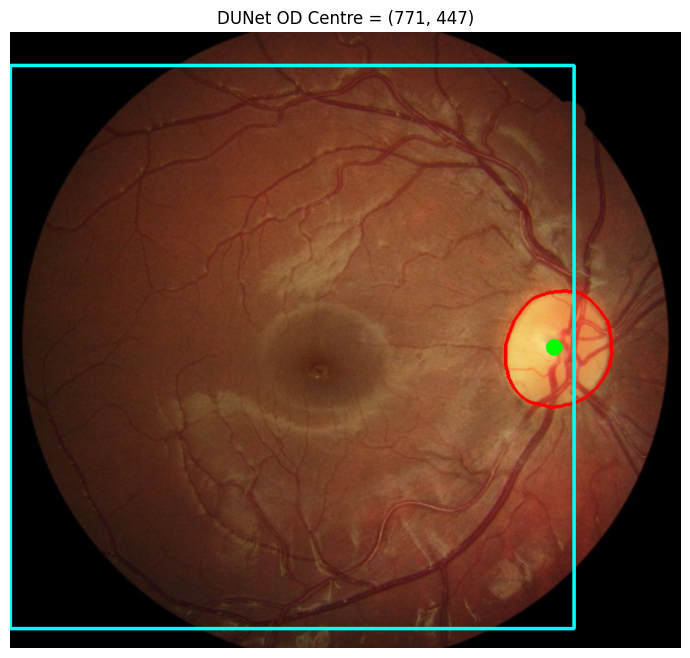

In [47]:
overlay = img_rgb.copy()

# Draw DUNet contour
cv2.drawContours(
    overlay,
    [best_contour],
    -1,
    (255, 0, 0),
    3
)

# Draw centre
cv2.circle(
    overlay,
    centre,
    12,
    (0, 255, 0),
    -1
)

# --------------------------------------------------
# Draw a TRUE 800 x 800 square crop boundary
# while keeping the entire square inside the image
# --------------------------------------------------

cx, cy = centre

crop_size = 800
half = crop_size // 2

img_h, img_w = img_rgb.shape[:2]

# Initial square centered on the detected OD
left = cx - half * 2
top = cy - half
right = left + crop_size
bottom = top + crop_size

# Shift horizontally if the square exceeds image bounds
if left < 0:
    left = 0
    right = crop_size

if right > img_w:
    right = img_w
    left = img_w - crop_size

# Shift vertically if the square exceeds image bounds
if top < 0:
    top = 0
    bottom = crop_size

if bottom > img_h:
    bottom = img_h
    top = img_h - crop_size

# Draw the corrected square
cv2.rectangle(
    overlay,
    (left, top),
    (right - 1, bottom - 1),
    (0, 255, 255),
    3
)

print("OD centre:", (cx, cy))
print("Square crop:", (left, top, right, bottom))
print("Crop size:", right - left, "x", bottom - top)

plt.figure(figsize=(10, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title(f"DUNet OD Centre = ({cx}, {cy})")
plt.show()

In [49]:
def centre_crop_with_validity(
    centre,
    image_original,
    crop_size=800
):
    """
    Create an exactly crop_size x crop_size crop centred on the OD.

    Returns:
        cropped_image : 800x800x3
        valid_mask    : 800x800
                       1 = original image pixel
                       0 = artificial padding
    """

    cx, cy = centre

    h, w = image_original.shape[:2]
    half = crop_size // 2

    # Desired crop in ORIGINAL image coordinates
    left = cx - half
    top = cy - half
    right = left + crop_size
    bottom = top + crop_size

    # --------------------------------------------------
    # Create black-padded crop
    # --------------------------------------------------

    cropped_image = np.zeros(
        (crop_size, crop_size, 3),
        dtype=np.uint8
    )

    # --------------------------------------------------
    # Valid region in original image
    # --------------------------------------------------

    src_left = max(left, 0)
    src_top = max(top, 0)

    src_right = min(right, w)
    src_bottom = min(bottom, h)

    # --------------------------------------------------
    # Corresponding destination coordinates
    # --------------------------------------------------

    dst_left = src_left - left
    dst_top = src_top - top

    dst_right = dst_left + (src_right - src_left)
    dst_bottom = dst_top + (src_bottom - src_top)

    # --------------------------------------------------
    # Copy real image pixels
    # --------------------------------------------------

    cropped_image[
        dst_top:dst_bottom,
        dst_left:dst_right
    ] = image_original[
        src_top:src_bottom,
        src_left:src_right
    ]

    # --------------------------------------------------
    # Validity mask
    # --------------------------------------------------

    valid_mask = np.zeros(
        (crop_size, crop_size),
        dtype=np.uint8
    )

    valid_mask[
        dst_top:dst_bottom,
        dst_left:dst_right
    ] = 1

    return cropped_image, valid_mask

In [50]:
cropped_img, crop_valid = centre_crop_with_validity(
    centre=centre,
    image_original=img_rgb,
    crop_size=800
)

print("Original:", img_rgb.shape)
print("Centre:", centre)
print("Crop:", cropped_img.shape)
print("Valid pixels:", crop_valid.sum())
print("Padded pixels:", (crop_valid == 0).sum())

Original: (874, 951, 3)
Centre: (771, 447)
Crop: (800, 800, 3)
Valid pixels: 464000
Padded pixels: 176000


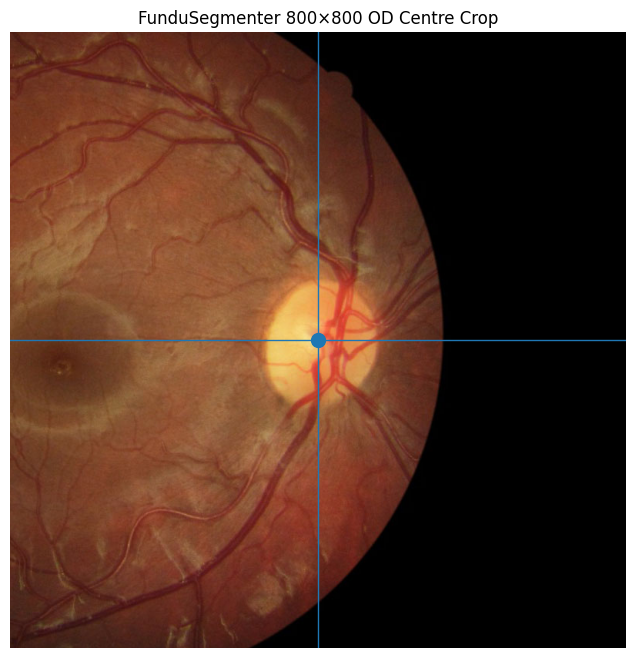

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cropped_img)

plt.axvline(400, linewidth=1)
plt.axhline(400, linewidth=1)
plt.scatter([400], [400], s=100)

plt.title("FunduSegmenter 800×800 OD Centre Crop")
plt.axis("off")
plt.show()

In [52]:
from utils.transform import validation_transform

# Official FunduSegmenter input size
image_size = 224

transform_image, transform_both = validation_transform(image_size)

# Apply exactly the same transformation used by test.py
transformed = transform_image(image=cropped_img)

model_input = transformed["image"]

print("Crop:", cropped_img.shape)
print("Model input:", model_input.shape)
print("dtype:", model_input.dtype)
print("min:", model_input.min().item())
print("max:", model_input.max().item())

Crop: (800, 800, 3)
Model input: (224, 224, 3)
dtype: float32
min: -2.1179039478302
max: 2.1461596488952637


In [53]:
model.eval()

x = torch.from_numpy(model_input).permute(2, 0, 1).unsqueeze(0).float().to(device)

print("Input to FunduSegmenter:", x.shape)
print("dtype:", x.dtype)
print("device:", x.device)

with torch.no_grad():
    output = model(x)

print("Output type:", type(output))
print("Output shape:", output.shape)

Input to FunduSegmenter: torch.Size([1, 3, 224, 224])
dtype: torch.float32
device: cuda:0
Output type: <class 'torch.Tensor'>
Output shape: torch.Size([1, 3, 224, 224])


In [54]:
pred = torch.argmax(output, dim=1)

pred = pred.squeeze(0).cpu().numpy()

print("Prediction shape:", pred.shape)
print("Unique classes:", np.unique(pred))

Prediction shape: (224, 224)
Unique classes: [0 1 2]


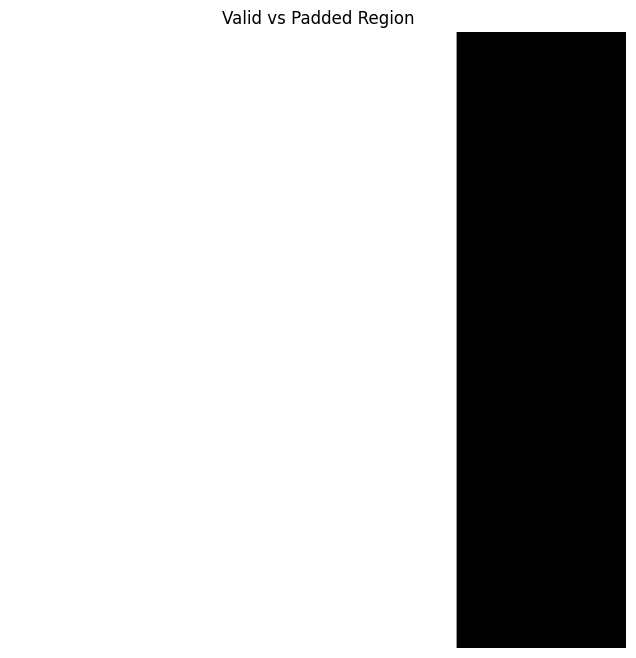

In [55]:
plt.figure(figsize=(8, 8))
plt.imshow(crop_valid, cmap="gray")
plt.title("Valid vs Padded Region")
plt.axis("off")
plt.show()

In [56]:
import cv2
import numpy as np

# Resize validity mask to FunduSegmenter's prediction resolution
crop_valid_224 = cv2.resize(
    crop_valid,
    (224, 224),
    interpolation=cv2.INTER_NEAREST
)

print("Prediction:", pred.shape)
print("Validity mask:", crop_valid_224.shape)

cup_mask = (pred == 0)
disc_mask = (pred == 1)

# Complete optic disc = disc rim + cup
full_od_mask = (pred == 0) | (pred == 1)

background_mask = (pred == 2)

# ============================================================
# CORRECT FUNDUSEGMENTER CLASS MASKS
# ============================================================

cup_mask = (pred == 0)
disc_mask = (pred == 1)
background_mask = (pred == 2)

# Full OD includes both the disc rim and the cup
full_od_mask = cup_mask | disc_mask


# ============================================================
# STATISTICS
# ============================================================

total_cup = np.sum(cup_mask)
total_disc = np.sum(disc_mask)
total_full_od = np.sum(full_od_mask)

valid_cup = np.sum(
    cup_mask & (crop_valid_224 == 1)
)

valid_disc = np.sum(
    disc_mask & (crop_valid_224 == 1)
)

valid_full_od = np.sum(
    full_od_mask & (crop_valid_224 == 1)
)

padding_cup = np.sum(
    cup_mask & (crop_valid_224 == 0)
)

padding_disc = np.sum(
    disc_mask & (crop_valid_224 == 0)
)

padding_full_od = np.sum(
    full_od_mask & (crop_valid_224 == 0)
)


print()
print("=" * 60)
print("FunduSegmenter segmentation statistics")
print("=" * 60)

print("Cup pixels:", total_cup)
print("Disc pixels:", total_disc)
print("Full OD pixels:", total_full_od)

print()
print("Cup inside valid image:", valid_cup)
print("Disc inside valid image:", valid_disc)
print("Full OD inside valid image:", valid_full_od)

print()
print("Cup inside padding:", padding_cup)
print("Disc inside padding:", padding_disc)
print("Full OD inside padding:", padding_full_od)

print()
print(
    "Full OD percentage in padding:",
    100 * padding_full_od / max(total_full_od, 1)
)

print("=" * 60)

# print("Total predicted OD pixels:", total_od)
# print("OD pixels inside valid image:", valid_od)
# print("OD pixels inside padding:", padding_od)

# print(
#     "Percentage of predicted OD in padding:",
#     100 * padding_od / max(total_od, 1)
# )


Prediction: (224, 224)
Validity mask: (224, 224)

FunduSegmenter segmentation statistics
Cup pixels: 48306
Disc pixels: 1571
Full OD pixels: 49877

Cup inside valid image: 34642
Disc inside valid image: 1571
Full OD inside valid image: 36213

Cup inside padding: 13664
Disc inside padding: 0
Full OD inside padding: 13664

Full OD percentage in padding: 27.39539266595826


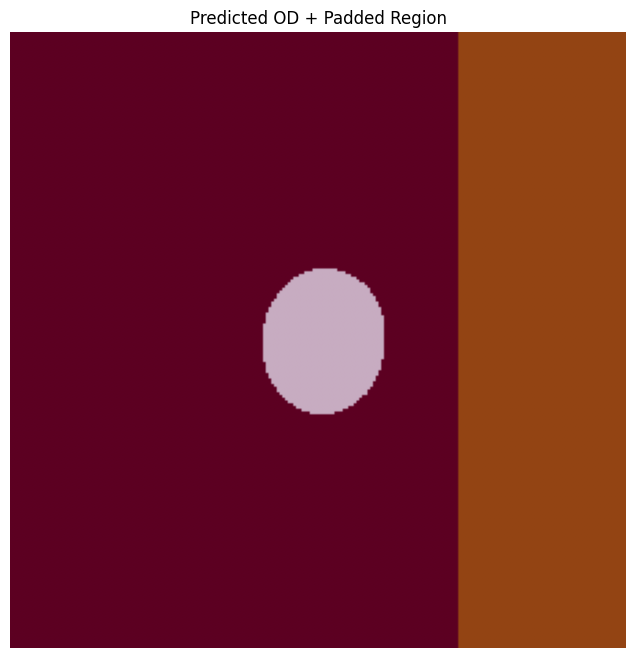

In [57]:
plt.figure(figsize=(8, 8))
plt.imshow(pred == 0, cmap="Reds")
plt.imshow(crop_valid_224 == 0, alpha=0.3)
plt.title("Predicted OD + Padded Region")
plt.axis("off")
plt.show()

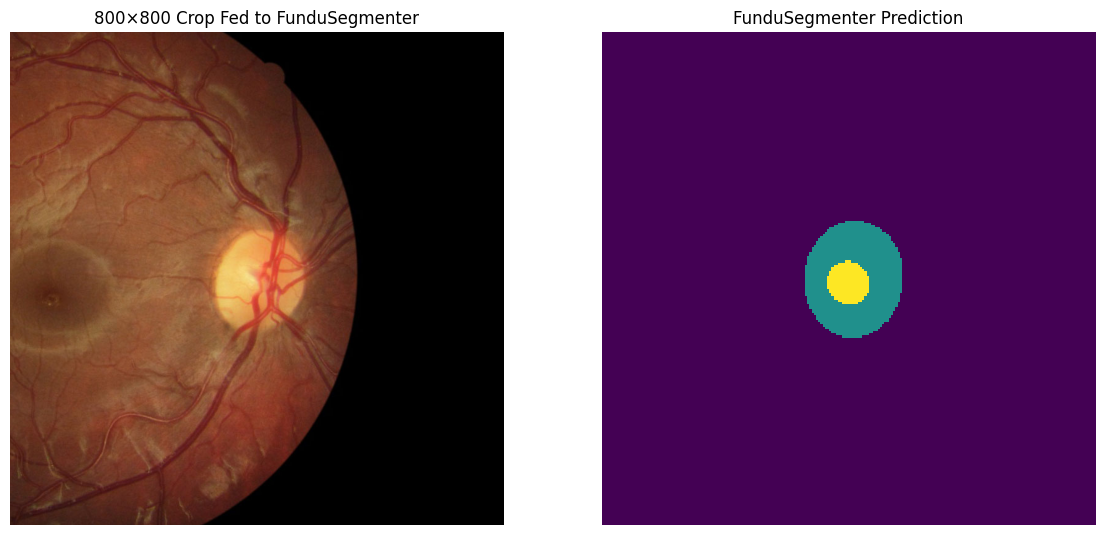

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(cropped_img)
ax[0].set_title("800×800 Crop Fed to FunduSegmenter")
ax[0].axis("off")

ax[1].imshow(pred, interpolation="nearest")
ax[1].set_title("FunduSegmenter Prediction")
ax[1].axis("off")

plt.show()

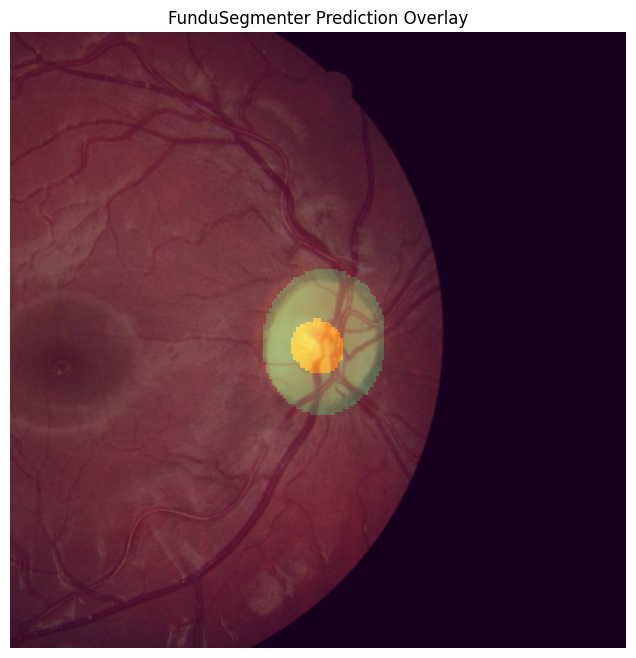

In [59]:
pred_800 = cv2.resize(
    pred.astype(np.uint8),
    (800, 800),
    interpolation=cv2.INTER_NEAREST
)

plt.figure(figsize=(8, 8))
plt.imshow(cropped_img)
plt.imshow(
    pred_800,
    alpha=0.35,
    interpolation="nearest"
)
plt.title("FunduSegmenter Prediction Overlay")
plt.axis("off")
plt.show()